# 09 · Decision Trees & Random Forests

**Difficulty:** Intermediate | **Time:** ~3 hours

Decision Trees are the building blocks of the most powerful algorithms in practice.

## Table of Contents
1. Decision Tree Theory
2. Building & Visualizing a Tree
3. Overfitting & Pruning
4. Feature Importance
5. Random Forest — Ensemble of Trees
6. Hyperparameter Tuning (GridSearchCV)
7. Real-World Project: Customer Churn

## 1. How a Decision Tree Works

A decision tree splits data by asking YES/NO questions at each node:

```
      [Income > 50000?]
       /             \
     YES              NO
  [Age > 30?]    → Predict: No Loan
   /      \
 YES      NO
→ Approve  → Review
```

**Splitting criterion:** 
- Gini Impurity: $G = 1 - \sum p_i^2$ 
- Entropy: $H = -\sum p_i \log_2(p_i)$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_breast_cancer, load_iris
import warnings
warnings.filterwarnings('ignore')
print("Libraries loaded ✓")

Libraries loaded ✓


## 2. Building a Decision Tree — Step by Step

In [2]:
# Simple dataset: will the customer buy?
np.random.seed(42)
n = 400
age     = np.random.randint(20, 65, n)
income  = np.random.randint(20000, 120000, n)
savings = np.random.randint(0, 50000, n)

# Rule: buys if (income > 60000 AND age > 30) OR savings > 30000
will_buy = ((income > 60000) & (age > 30)) | (savings > 30000)
will_buy = will_buy.astype(int)

df = pd.DataFrame({'age':age,'income':income,'savings':savings,'will_buy':will_buy})
X = df.drop('will_buy', axis=1)
y = df['will_buy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Shallow tree (interpretable)
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

print("Decision Tree (max_depth=3):")
print(export_text(dt, feature_names=list(X.columns)))
print(f"\nAccuracy: {dt.score(X_test, y_test):.2%}")

Decision Tree (max_depth=3):
|--- savings <= 29823.50
|   |--- income <= 59182.00
|   |   |--- class: 0
|   |--- income >  59182.00
|   |   |--- age <= 31.00
|   |   |   |--- class: 0
|   |   |--- age >  31.00
|   |   |   |--- class: 1
|--- savings >  29823.50
|   |--- class: 1


Accuracy: 97.50%


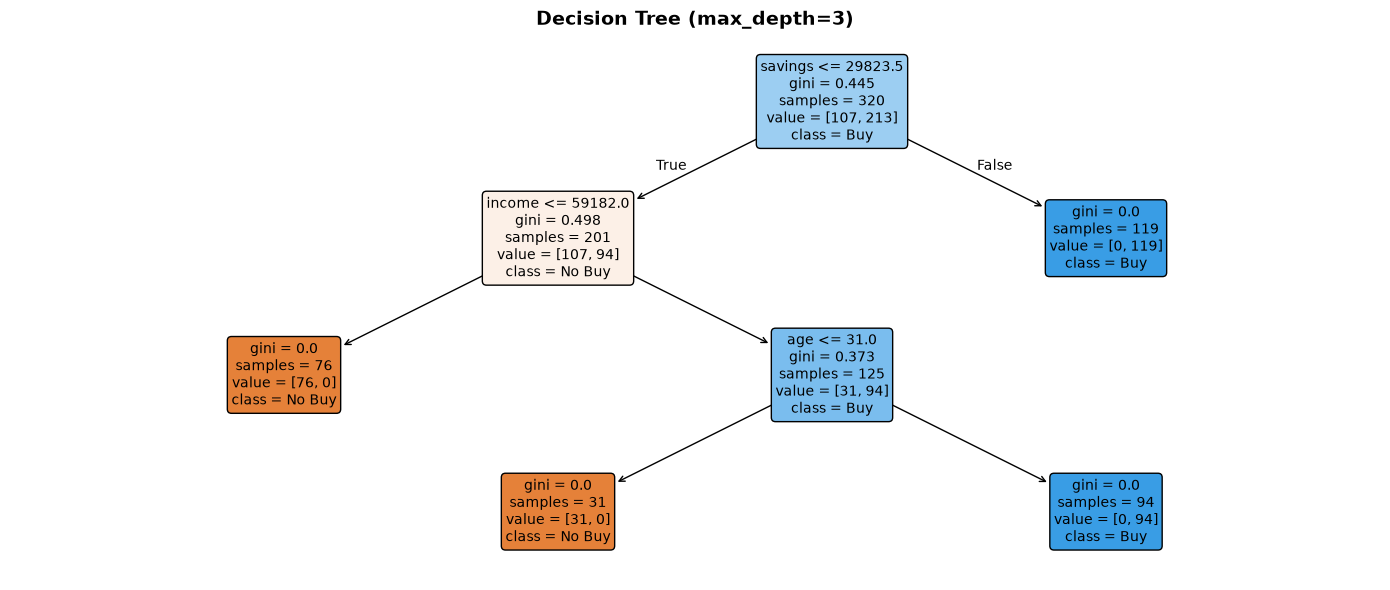

In [3]:
# Visualize the tree
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(dt, feature_names=X.columns, class_names=['No Buy','Buy'],
          filled=True, rounded=True, fontsize=10, ax=ax)
ax.set_title("Decision Tree (max_depth=3)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/decision_tree.png", dpi=100)
plt.show()

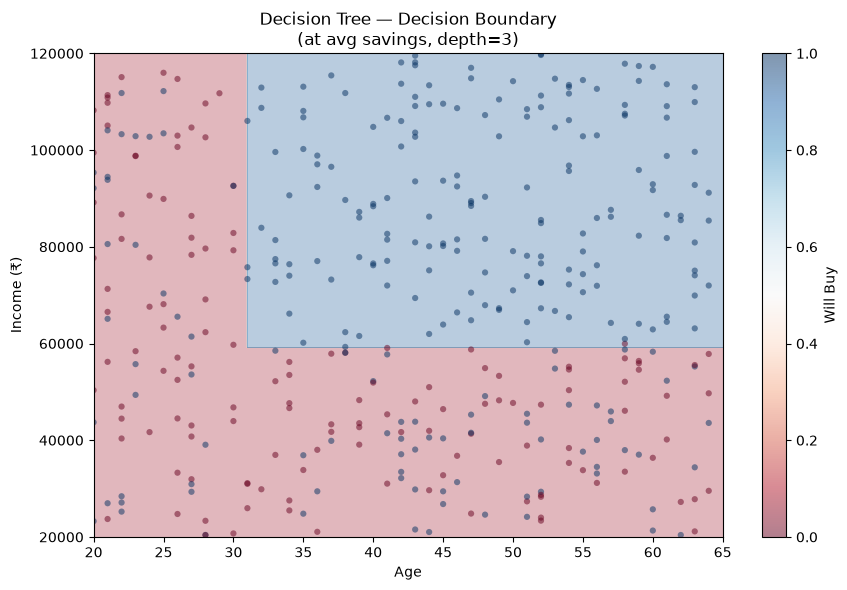

In [4]:
# Decision boundary visualization (2D: age vs income)
fig, ax = plt.subplots(figsize=(9, 6))

# Create mesh grid
h = 500
xx, yy = np.meshgrid(np.linspace(20, 65, h), np.linspace(20000, 120000, h))
mesh_savings = np.full(xx.ravel().shape, df['savings'].mean())
mesh_input = np.c_[xx.ravel(), yy.ravel(), mesh_savings]
Z = dt.predict(mesh_input).reshape(xx.shape)

ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
scatter = ax.scatter(df['age'], df['income'], c=df['will_buy'],
                      cmap='RdBu', alpha=0.5, s=20, edgecolors='none')
ax.set_xlabel("Age"); ax.set_ylabel("Income (₹)")
ax.set_title("Decision Tree — Decision Boundary\n(at avg savings, depth=3)")
plt.colorbar(scatter, label='Will Buy')
plt.tight_layout()
plt.savefig("/tmp/dt_boundary.png", dpi=100)
plt.show()

## 3. Overfitting — The Key Problem with Trees

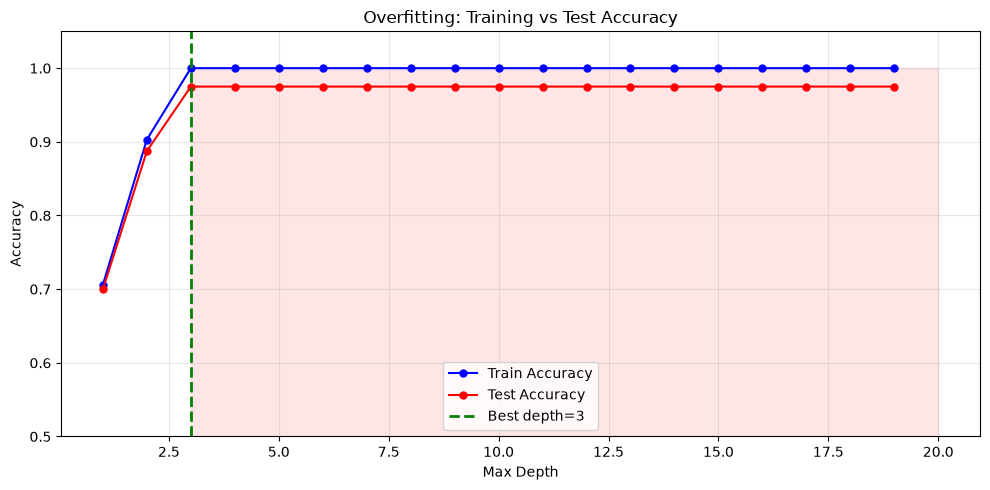

Best depth: 3 → Test accuracy: 97.50%


In [5]:
# Compare tree depth vs accuracy
train_accs, test_accs = [], []
depths = range(1, 20)

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_accs.append(dt.score(X_train, y_train))
    test_accs.append(dt.score(X_test, y_test))

best_depth = depths[np.argmax(test_accs)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_accs, 'b-o', ms=5, label='Train Accuracy')
ax.plot(depths, test_accs,  'r-o', ms=5, label='Test Accuracy')
ax.axvline(best_depth, color='green', linestyle='--', linewidth=2, label=f'Best depth={best_depth}')
ax.set_xlabel("Max Depth"); ax.set_ylabel("Accuracy")
ax.set_title("Overfitting: Training vs Test Accuracy")
ax.legend(); ax.grid(alpha=0.3)

# Shade overfitting zone
ax.fill_betweenx([0, 1], best_depth, 20, alpha=0.1, color='red', label='Overfitting zone')
ax.set_ylim(0.5, 1.05)

plt.tight_layout()
plt.savefig("/tmp/dt_overfitting.png", dpi=100)
plt.show()
print(f"Best depth: {best_depth} → Test accuracy: {max(test_accs):.2%}")

## 4. Random Forest — Wisdom of the Crowd

Random Forest = many trees → vote → better predictions

```
 Data → [Tree 1] [Tree 2] [Tree 3] ... [Tree N]
                  ↓
           Majority Vote → Final Prediction
```

**Why better?** Each tree sees a random subset of data AND features → diversity → less overfitting

In [6]:
# Compare: Single Tree vs Random Forest
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target
X_tr, X_te, y_tr, y_te = train_test_split(X_bc, y_bc, test_size=0.2, 
                                            random_state=42, stratify=y_bc)

# Single Decision Tree
dt_single = DecisionTreeClassifier(random_state=42)
dt_single.fit(X_tr, y_tr)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_tr, y_tr)

print(f"{'Model':<25} {'Train Acc':>10} {'Test Acc':>10} {'CV Acc':>10}")
print("-" * 55)
for name, model in [("Decision Tree (full)", dt_single), ("Random Forest (100)", rf)]:
    tr_acc = model.score(X_tr, y_tr)
    te_acc = model.score(X_te, y_te)
    cv_acc = cross_val_score(model, X_bc, y_bc, cv=5).mean()
    print(f"{name:<25} {tr_acc:>10.2%} {te_acc:>10.2%} {cv_acc:>10.2%}")

Model                      Train Acc   Test Acc     CV Acc
-------------------------------------------------------
Decision Tree (full)         100.00%     91.23%     91.73%


Random Forest (100)          100.00%     95.61%     95.61%


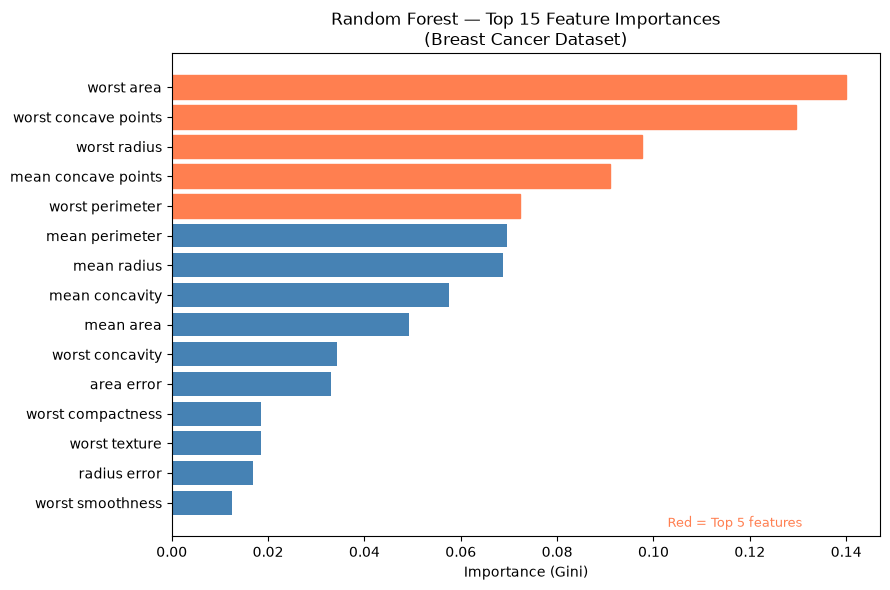

In [7]:
# Feature importance from Random Forest
feat_imp = pd.DataFrame({
    'Feature': bc.feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue')
ax.set_title("Random Forest — Top 15 Feature Importances\n(Breast Cancer Dataset)")
ax.set_xlabel("Importance (Gini)")

# Highlight top 5
for i, bar in enumerate(bars):
    if i >= 10:
        bar.set_color('coral')
        
ax.text(0.7, 0.02, 'Red = Top 5 features', transform=ax.transAxes, 
        fontsize=9, color='coral')
plt.tight_layout()
plt.savefig("/tmp/rf_importance.png", dpi=100)
plt.show()

## 5. Hyperparameter Tuning with GridSearchCV

In [8]:
# Find the best combination of hyperparameters
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                            param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_tr, y_tr)

print("Best Parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV Score : {grid_search.best_score_:.2%}")
print(f"Test Accuracy : {grid_search.score(X_te, y_te):.2%}")

Best Parameters:
  max_depth: None
  max_features: sqrt
  min_samples_split: 2
  n_estimators: 200

Best CV Score : 96.04%
Test Accuracy : 95.61%


## 6. Real-World Project: Customer Churn Prediction

In [9]:
# Telecom customer churn dataset
np.random.seed(42)
n = 3000

churn_data = pd.DataFrame({
    'tenure_months'    : np.random.randint(1, 72, n),
    'monthly_charges'  : np.random.uniform(20, 120, n),
    'total_charges'    : np.random.uniform(100, 8000, n),
    'num_products'     : np.random.randint(1, 6, n),
    'has_support_calls': np.random.randint(0, 10, n),
    'payment_delays'   : np.random.randint(0, 5, n),
    'contract_type'    : np.random.choice([0, 1, 2], n),  # Month/Year/2Year
    'online_security'  : np.random.randint(0, 2, n),
})

# Churn probability
churn_prob = (0.8
              - churn_data['tenure_months'] / 150
              + churn_data['has_support_calls'] * 0.06
              + churn_data['payment_delays'] * 0.1
              - churn_data['num_products'] * 0.05
              - churn_data['contract_type'] * 0.15
              + np.random.normal(0, 0.2, n))
churn_prob = 1 / (1 + np.exp(-churn_prob * 3))
churn_data['churned'] = (np.random.random(n) < churn_prob).astype(int)

print(f"Churn rate: {churn_data['churned'].mean():.1%}")
print(churn_data.head())

Churn rate: 85.9%
   tenure_months  monthly_charges  total_charges  num_products  \
0             52        85.735348    5063.942229             5   
1             15        67.228180    1554.400455             2   
2             61       108.015674     934.637729             3   
3             21        41.574068    6521.522675             3   
4             24        87.781320    4672.176163             3   

   has_support_calls  payment_delays  contract_type  online_security  churned  
0                  2               1              0                0        0  
1                  3               3              2                0        1  
2                  3               2              1                0        1  
3                  7               4              2                0        1  
4                  5               3              1                0        1  


In [10]:
X_ch = churn_data.drop('churned', axis=1)
y_ch = churn_data['churned']

X_tr_ch, X_te_ch, y_tr_ch, y_te_ch = train_test_split(
    X_ch, y_ch, test_size=0.2, random_state=42, stratify=y_ch)

# Train Random Forest
rf_churn = RandomForestClassifier(n_estimators=200, max_depth=10, 
                                   class_weight='balanced', random_state=42)
rf_churn.fit(X_tr_ch, y_tr_ch)
y_pred_ch = rf_churn.predict(X_te_ch)

print("Customer Churn Prediction:")
print(classification_report(y_te_ch, y_pred_ch, target_names=['Retained','Churned']))

Customer Churn Prediction:
              precision    recall  f1-score   support

    Retained       0.25      0.31      0.27        85
     Churned       0.88      0.85      0.86       515

    accuracy                           0.77       600
   macro avg       0.56      0.58      0.57       600
weighted avg       0.79      0.77      0.78       600



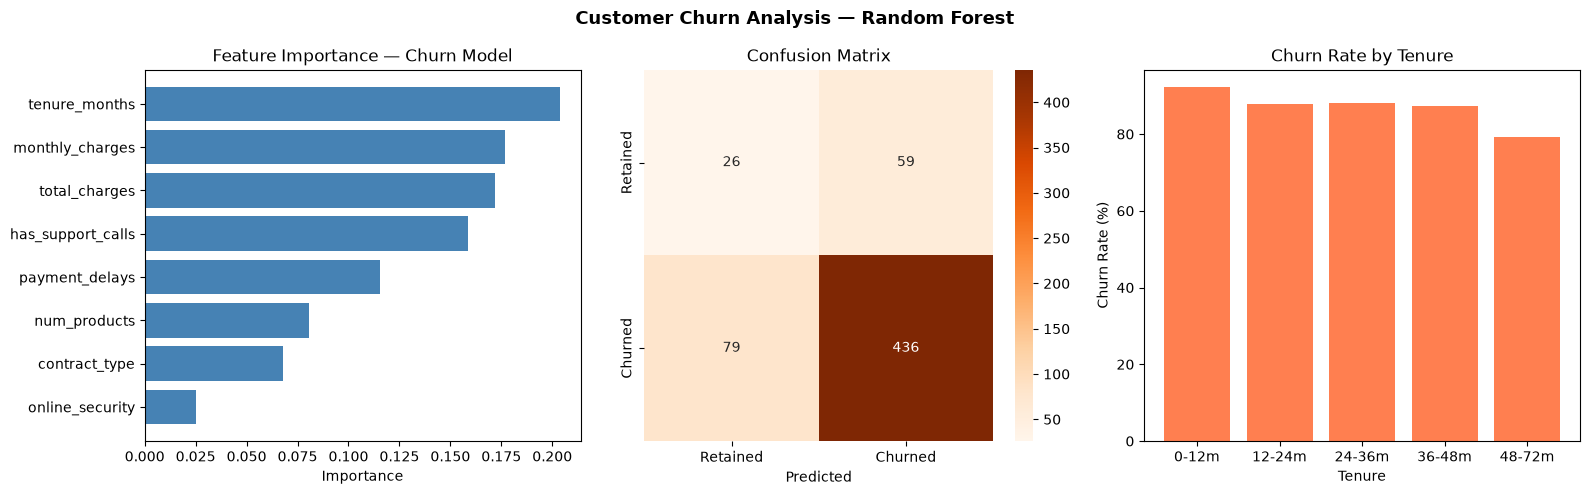

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Feature Importance
imp_df = pd.DataFrame({
    'Feature': X_ch.columns,
    'Importance': rf_churn.feature_importances_
}).sort_values('Importance', ascending=True)

axes[0].barh(imp_df['Feature'], imp_df['Importance'], color='steelblue')
axes[0].set_title("Feature Importance — Churn Model")
axes[0].set_xlabel("Importance")

# Confusion Matrix
cm = confusion_matrix(y_te_ch, y_pred_ch)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Retained','Churned'], yticklabels=['Retained','Churned'])
axes[1].set_title("Confusion Matrix"); axes[1].set_xlabel("Predicted")

# Churn rate by tenure bucket
churn_data['tenure_bucket'] = pd.cut(churn_data['tenure_months'],
                                      bins=[0,12,24,36,48,72],
                                      labels=['0-12m','12-24m','24-36m','36-48m','48-72m'])
churn_by_tenure = churn_data.groupby('tenure_bucket')['churned'].mean()
axes[2].bar(churn_by_tenure.index, churn_by_tenure*100, color='coral')
axes[2].set_title("Churn Rate by Tenure")
axes[2].set_xlabel("Tenure"); axes[2].set_ylabel("Churn Rate (%)")

plt.suptitle("Customer Churn Analysis — Random Forest", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/churn_analysis.png", dpi=100)
plt.show()

## Summary

| Algorithm | Pros | Cons |
|---|---|---|
| Decision Tree | Interpretable, fast | Overfits easily |
| Random Forest | High accuracy, handles noise | Slower, less interpretable |

**Hyperparameters to tune:**
- `max_depth`: prevents overfitting
- `n_estimators`: more trees = better (but slower)
- `min_samples_split`: min samples to split a node
- `max_features`: random feature subset per split

**Next notebook →** `10_SVM_KNN.ipynb`